<a href="https://colab.research.google.com/github/satani99/triton_kernels/blob/main/intro_to_triton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from IPython.core.debugger import set_trace

os.environ['TRITON_INTERPRET'] = '1'

def check_tensors_gpu_ready(*tensors):
  for t in tensors:
    assert t.is_contiguous, "A tensor is not contiguous"
    if not os.environ.get('TRITON_INTERPRET') == '1': assert t.is_cuda, "A tensor is not on cuda"

def test_pid_conds(conds, pid_0=[0], pid_1=[0], pid_2=[0]):
  '''Test if condition on pids are fulfilled
  E.g.:
    '=0' checks that pid_0 == 0
    '>1' checks that pid_1 > 1
    '>1,=0' checks that pid_0 > 1 and pid_1 == 0
  '''
  pids = pid_0[0], pid_1[0], pid_2[0]
  conds = conds.replace(' ', '').split(',')
  for i, (cond, pid) in enumerate(zip(conds, pids)):
    if cond=='': continue
    op, threshold = cond[0], int(cond[1:])
    if op not in ['<', '>', '>=', '<=', '=', '!=']: raise ValueError(f"Rules may only use these ops: '<', '>', '>=', '<=', '=', '!='. Invalid rule: '{condition}'.")
    op = '==' if op == '=' else op
    if not eval(f'{pid} {op} {threshold}'): return False
  return True

assert test_pid_conds('')
assert test_pid_conds('>0', [1], [1])
assert not test_pid_conds('>0', [0], [1])
assert test_pid_conds('=0,=1', [0], [1], [0])

def breakpoint_if(conds, pid_0=[0], pid_1=[0], pid_2=[0]):
  '''Stop kernel, if any condition of pids is fulfilled'''
  if test_pid_conds(conds, pid_0, pid_1, pid_2): set_trace()

def print_if(txt, conds, pid_0=[0], pid_1=[0], pid_2=[0]):
  '''Print txt, if any condition of pids is fulfilled'''
  if test_pid_conds(conds, pid_0, pid_1, pid_2): print(txt)

def cdiv(a, b): return (a + b - 1) // b
assert cdiv(10, 2) == 5
assert cdiv(10, 3) == 4

In [ ]:
import torch
import triton
import triton.language as tl

# Copying a tensor

In [ ]:
def copy(x, bs, kernel_fn):
  z = torch.zeros_like(x)
  check_tensors_gpu_ready(x, z)
  n = x.numel()
  n_blocks = cdiv(n, bs)
  grid = (n_blocks, )

  kernel_fn[grid](x, z, n, bs)

  return z

In [ ]:
@triton.jit
def copy_k(x_ptr, z_ptr, n, bs: tl.constexpr):
  pid = tl.program_id(0)
  offs = pid * bs + tl.arange(0, bs)
  mask = offs < n
  x = tl.load(x_ptr + offs, mask)
  tl.store(z_ptr + offs, x, mask)
  print_if(f'pid = {pid} | offs = {offs}, mask = {mask}, x = {x}', '')


In [ ]:
z = copy(x, bs=2, kernel_fn=copy_k)

pid = [0] | offs = [0 1], mask = [ True  True], x = [1 2]
pid = [1] | offs = [2 3], mask = [ True  True], x = [3 4]
pid = [2] | offs = [4 5], mask = [ True  True], x = [5 6]


In [ ]:
x, z

(tensor([1, 2, 3, 4, 5, 6]), tensor([1, 2, 3, 4, 5, 6]))

In [ ]:
!uv pip install triton

Using Python 3.12.13 environment at: /usr
Resolved 1 package in 109ms
Prepared 1 package in 3.61s
Installed 1 package in 13ms
 + triton==3.6.0


# Greyscaling an image

In [ ]:
import os

import matplotlib.pyplot as plt
from urllib.request import urlretrieve
from pathlib import Path

import torch
from torch import tensor
import torchvision as tv
import torchvision.transforms.functional as tvf
from torchvision import io

import triton
import triton.language as tl

In [ ]:
def cdiv(a, b): return (a + b - 1) // b

In [ ]:
path_img = Path('puppy.jpg')
url = 'https://upload.wikimedia.org/wikipedia/commons/4/43/Cute_dog.jpg'
if not path_img.exists():
  import urllib.request
  # Create an opener to add a User-Agent header
  # This can help bypass HTTP 403 Forbidden errors from servers that block requests without a proper User-Agent
  opener = urllib.request.build_opener()
  opener.addheaders = [('User-agent', 'Mozilla/5.0')]
  urllib.request.install_opener(opener)
  urllib.request.urlretrieve(url, path_img)

In [ ]:
img = io.read_image('puppy.jpg')
print(img.shape)
img[:2, :3, :4]

torch.Size([3, 2117, 3176])


tensor([[[118, 118, 120, 119],
         [118, 125, 119, 117],
         [112, 120, 120, 125]],

        [[ 79,  81,  82,  83],
         [ 81,  90,  83,  82],
         [ 72,  84,  86,  91]]], dtype=torch.uint8)

In [ ]:
def show_img(x, figsize=(4,3), **kwargs):
  plt.figure(figsize=figsize)
  plt.axis('off')
  if len(x.shape)==3: x = x.permute(1, 2, 0)
  plt.imshow(x.cpu(), **kwargs)

In [ ]:
img = tvf.resize(img, 150, antialias=True)
ch, h, w = img.shape
ch, h, w, h*w

(3, 150, 225, 33750)

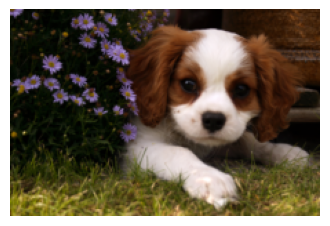

In [ ]:
show_img(img)

In [1]:
!uv pip install triton

Using Python 3.12.13 environment at: /usr
Checked 1 package in 182ms


In [2]:
import torch
import triton
import triton.language as tl

In [6]:
k = (2.0 / torch.pi) ** 0.5

@triton.jit
def gelu_kernel(
    output_buffer,
    input_buffer,
    input_row_stride,
    output_row_stride,
    n_cols,
    k: tl.constexpr,
    block_size: tl.constexpr,
):
  row_idx = tl.program_id(0)
  row_start_ptr = row_idx * input_row_stride + input_buffer

  col_offsets = tl.arange(0, block_size)
  input_ptrs = row_start_ptr + col_offsets

  row = tl.load(input_ptrs, mask=col_offsets < n_cols, other=-float('inf'))

  t = (row + 0.044715 * row * row * row) * k
  numerator = 2
  denominator = (1 + tl.exp(-2 * t))
  gelu_output = 0.5 * row * (1 + (numerator / denominator) - 1)

  output_row_start_ptr = output_buffer + row_idx * output_row_stride
  output_ptrs = output_row_start_ptr + col_offsets
  tl.store(output_ptrs, gelu_output, mask=col_offsets < n_cols)


In [7]:
def gelu(x: torch.Tensor):
  n_rows, n_cols = x.shape

  block_size = triton.next_power_of_2(n_cols)

  num_warps = 4

  if block_size >= 2048:
    num_warps = 8

  if block_size >= 4096:
    num_warps = 16

  y = torch.empty_like(x)

  gelu_kernel[(n_rows,)](
      y,
      x,
      x.stride(0),
      y.stride(0),
      n_cols,
      num_warps=num_warps,
      k=k,
      block_size=block_size,
  )

  return y

In [8]:
torch.manual_seed(42)
x = torch.randn(4097, 311, device='cuda')
y_triton = gelu(x)
y_torch = torch.nn.functional.gelu(x, approximate='tanh')
assert torch.allclose(y_triton,y_torch, rtol=1e-04, atol=1e-04), (y_triton, y_torch)

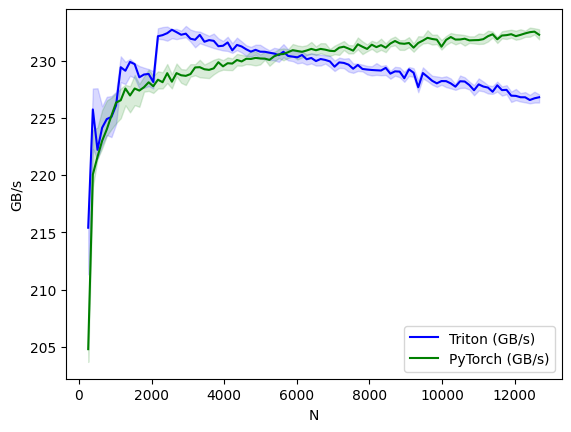

gelu-performance:
          N  Triton (GB/s)  PyTorch (GB/s)
0     256.0     215.401816      204.800005
1     384.0     225.726752      220.042531
2     512.0     222.203005      221.592553
3     640.0     224.131334      222.987409
4     768.0     224.887612      223.990888
5     896.0     225.071510      225.181989
6    1024.0     226.083660      226.327644
7    1152.0     229.414234      226.528663
8    1280.0     229.106799      227.555552
9    1408.0     229.877559      226.946633
10   1536.0     229.682243      227.555555
11   1664.0     228.532190      227.373372
12   1792.0     228.775469      227.668489
13   1920.0     228.826809      228.096749
14   2048.0     228.124868      227.753251
15   2176.0     232.118748      228.325032
16   2304.0     232.214172      228.105572
17   2432.0     232.386325      228.894119
18   2560.0     232.685965      228.149687
19   2688.0     232.475679      228.899135
20   2816.0     232.247431      228.710658
21   2944.0     232.343432      228.

In [9]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],  # argument names to use as an x-axis for the plot
        x_vals=[128 * i for i in range(2, 100)],  # different possible values for `x_name`
        line_arg='provider',  # argument name whose value corresponds to a different line in the plot
        line_vals=[
            'triton',
            'pytorch',
        ],  # possible values for `line_arg``
        line_names=[
            "Triton",
            "PyTorch",
        ],  # label name for the lines
        styles=[('blue', '-'), ('green', '-'), ('green', '--')],  # line styles
        ylabel="GB/s",  # label name for the y-axis
        plot_name="gelu-performance",  # name for the plot. Used also as a file name for saving the plot.
        args={'M': 4096},  # values for function arguments not in `x_names` and `y_name`
    ))
def benchmark(M, N, provider):
    x = torch.randn(M, N, device='cuda', dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'pytorch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.nn.functional.gelu(x), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: gelu(x), quantiles=quantiles)
    gbps = lambda ms: 2 * x.nelement() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(show_plots=True, print_data=True)